# Phase 5 - Training, version 1 hyperparameters

**In:** `data/featured`  
**Out:** MLflow run tagged `version=v1` in the `bike-demand` experiment

| Step | What |
| --- | --- |
| 1 | Setup - split, features, metrics |
| 2 | v1 hyperparameters |
| 3 | Train and log |
| 4 | Result vs baseline |

Phase 4 selected HistGradientBoosting with Poisson loss: it beat the
station-hour-weekday baseline by 11.1% MAE, while the Poisson GLM managed +0.1%
and was *worse* on RMSE. Only the winner is carried forward.

v1 is the untuned reference point. Phase 6 sweeps hyperparameters and must beat
this run to justify itself.

## Step 1 - Setup

Same split, features, and metrics as Phase 4 - v1 and v2 are only comparable if
the inputs are identical.

In [1]:
import os
from pathlib import Path

import duckdb
import mlflow
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

ML = Path("/opt/data/ml")
FEATURED = f"read_parquet('{ML}/featured/**/*.parquet', hive_partitioning=1)"

con = duckdb.connect()
con.execute("SET enable_progress_bar_print=false")

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("bike-demand")

TRAIN_YEARS, VAL_YEARS, TEST_YEARS = (2019, 2020, 2021), (2022,), (2023,)


def load(years):
    return con.execute(
        f"SELECT * FROM {FEATURED} WHERE year IN {years} ORDER BY start_date, hour"
    ).df()


train, val, test = load(TRAIN_YEARS), load(VAL_YEARS), load(TEST_YEARS)

assert train["start_date"].max() < val["start_date"].min(), "train/val overlap"
assert val["start_date"].max() < test["start_date"].min(), "val/test overlap"

print(f"train {len(train):>9,} | val {len(val):>9,} | test {len(test):>9,}")

train 1,999,104 | val   611,040 | test   665,760


In [2]:
TARGET = "trip_count"
CATEGORICAL = ["station_id", "season"]
NUMERIC = [
    "hour", "quarter", "month", "weekday", "week_of_year",
    "is_weekend", "is_holiday",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",
]
FEATURES = CATEGORICAL + NUMERIC
PEAK_HOURS = [7, 8, 9, 16, 17, 18, 19]

# year and start_date identify the split, not the demand pattern.
assert not (set(FEATURES) & {"year", "start_date", TARGET}), "split column leaked"


def score(y_true, y_pred, hours, label):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    y_true = np.asarray(y_true, dtype=float)
    peak = np.isin(hours, PEAK_HOURS)
    return {
        "model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE_peak": mean_absolute_error(y_true[peak], y_pred[peak]),
        "MAE_offpeak": mean_absolute_error(y_true[~peak], y_pred[~peak]),
    }


# Phase 4's baseline, recomputed so this notebook stands alone.
BASELINE_KEYS = ["station_id", "hour", "weekday"]
lookup = train.groupby(BASELINE_KEYS)[TARGET].mean().rename("baseline")
global_mean = train[TARGET].mean()
baseline_pred = (
    test[BASELINE_KEYS].join(lookup, on=BASELINE_KEYS)["baseline"]
    .fillna(global_mean).to_numpy()
)
baseline_scores = score(test[TARGET], baseline_pred, test["hour"], "baseline")

print(f"{len(FEATURES)} features -> {TARGET}")
print(f"baseline test MAE {baseline_scores['MAE']:.4f}")

15 features -> trip_count
baseline test MAE 1.9405


## Step 2 - v1 hyperparameters

sklearn defaults, unchanged from Phase 4. Deliberately untuned: v1 is the
reference, not an attempt at a good model.

`early_stopping` stays off. sklearn draws its internal validation holdout at
**random**, which on a time series would put 2021 rows in the stopping set while
training on 2019 - leakage that inflates the score.

In [3]:
V1_PARAMS = {
    "loss": "poisson",       # counts are non-negative and skewed
    "learning_rate": 0.1,
    "max_leaf_nodes": 31,
    "max_iter": 300,
    "min_samples_leaf": 20,
    "l2_regularization": 0.0,
    "early_stopping": False,
    "random_state": 0,
}

DATA_CONTEXT = {
    "rows_train": len(train),
    "rows_val": len(val),
    "rows_test": len(test),
    "n_stations": train["station_id"].nunique(),
    "train_years": str(TRAIN_YEARS),
    "val_years": str(VAL_YEARS),
    "test_years": str(TEST_YEARS),
    "features": ",".join(FEATURES),
}

pd.Series(V1_PARAMS).to_frame("v1")

,v1
loss,poisson
learning_rate,0.1
max_leaf_nodes,31
max_iter,300
min_samples_leaf,20
l2_regularization,0.0
early_stopping,False
random_state,0


## Step 3 - Train and log

In [4]:
def build(params):
    """season is the only string column; the rest pass through as numerics."""
    return Pipeline([
        ("prep", ColumnTransformer(
            [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
              ["season"])],
            remainder="passthrough",
        )),
        ("model", HistGradientBoostingRegressor(**params)),
    ])


def train_and_log(label, params, version):
    model = build(params)
    with mlflow.start_run(run_name=label) as run:
        mlflow.log_params(params)
        mlflow.set_tags({"model": "hist_gbm", "version": version, **DATA_CONTEXT})

        model.fit(train[FEATURES], train[TARGET])

        rows = []
        for split_name, df in [("val", val), ("test", test)]:
            s = score(df[TARGET], model.predict(df[FEATURES]), df["hour"], label)
            mlflow.log_metrics(
                {f"{split_name}_{k}": v for k, v in s.items() if k != "model"}
            )
            rows.append({"split": split_name, **s})

        mlflow.sklearn.log_model(model, name="model")
        run_id = run.info.run_id

    return model, pd.DataFrame(rows), run_id

In [5]:
%%time
v1_model, v1_scores, v1_run_id = train_and_log("hist_gbm_v1", V1_PARAMS, "v1")

print(f"run_id {v1_run_id}")
v1_scores

🏃 View run hist_gbm_v1 at: http://mlflow:5000/#/experiments/2/runs/36012b4709cf4cc3895848946e2bf504
🧪 View experiment at: http://mlflow:5000/#/experiments/2
run_id 36012b4709cf4cc3895848946e2bf504
CPU times: user 4min 13s, sys: 12.6 s, total: 4min 25s
Wall time: 1min 17s


,split,model,MAE,RMSE,MAE_peak,MAE_offpeak
0,val,hist_gbm_v1,1.408149,2.581822,2.007490,1.161361
1,test,hist_gbm_v1,1.725368,3.075830,2.663388,1.339125


## Step 4 - Result

The val->test gap is the number to watch. Training spans 2019-2021 and 2020-21
ridership was distorted by COVID, so a large gap points at the training years
rather than at the hyperparameters - which no amount of Phase 6 tuning fixes.

In [6]:
v1_test = v1_scores[v1_scores["split"] == "test"].iloc[0]
v1_val = v1_scores[v1_scores["split"] == "val"].iloc[0]

result = pd.DataFrame([baseline_scores, v1_test.drop("split")]).set_index("model")
result["vs_baseline"] = (
    1 - result["MAE"] / baseline_scores["MAE"]
).map("{:+.1%}".format)

print("test set (2023)\n")
print(result.to_string())
print(f"\nval MAE  {v1_val['MAE']:.4f}")
print(f"test MAE {v1_test['MAE']:.4f}")
print(f"gap      {v1_test['MAE'] / v1_val['MAE'] - 1:+.1%} "
      f"(degradation from 2022 to 2023)")

test set (2023)

                  MAE      RMSE  MAE_peak  MAE_offpeak vs_baseline
model                                                             
baseline     1.940476  3.360378  3.018116     1.496742       +0.0%
hist_gbm_v1  1.725368  3.075830  2.663388     1.339125      +11.1%

val MAE  1.4081
test MAE 1.7254
gap      +22.5% (degradation from 2022 to 2023)


## Step 5 - Visualize

Left: v1 against the baseline it has to beat. Right: the same model scored on
2022 and 2023 - the gap Phase 6 cannot tune away.

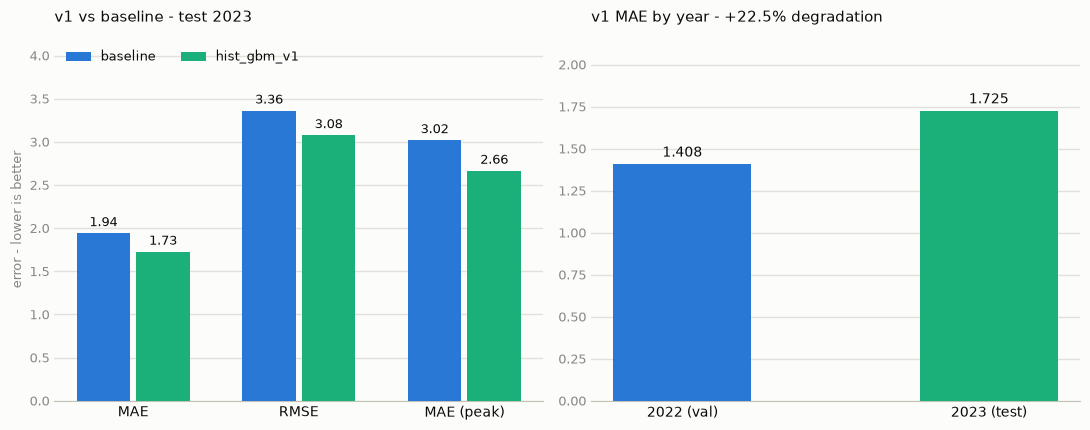

In [7]:
import matplotlib.pyplot as plt

# Validated categorical slots: blue = reference, aqua = the model.
BLUE, AQUA = "#2a78d6", "#1baf7a"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"

metrics = ["MAE", "RMSE", "MAE_peak"]
labels = ["MAE", "RMSE", "MAE (peak)"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4), facecolor=SURFACE)

# --- left: v1 vs baseline on the test set ---
x = np.arange(len(metrics))
width = 0.36
for i, (name, row, color) in enumerate(
    [("baseline", baseline_scores, BLUE), ("hist_gbm_v1", v1_test, AQUA)]
):
    bars = ax1.bar(x + (i - 0.5) * width, [row[k] for k in metrics],
                   width * 0.9, label=name, color=color, zorder=3)
    # aqua is below 3:1 on this surface, so values are labelled, not inferred
    ax1.bar_label(bars, fmt="%.2f", padding=3, fontsize=9, color=INK)

ax1.set_xticks(x, labels, fontsize=10, color=INK)
ax1.set_title("v1 vs baseline - test 2023", fontsize=11, color=INK, loc="left", pad=12)
ax1.set_ylabel("error - lower is better", fontsize=9, color=MUTED)
ax1.legend(frameon=False, ncols=2, loc="upper left", fontsize=9, labelcolor=INK)

# --- right: the same model, both evaluation years ---
gap_vals = [v1_val["MAE"], v1_test["MAE"]]
bars = ax2.bar(["2022 (val)", "2023 (test)"], gap_vals, 0.45,
               color=[BLUE, AQUA], zorder=3)
ax2.bar_label(bars, fmt="%.3f", padding=3, fontsize=10, color=INK)

gap = v1_test["MAE"] / v1_val["MAE"] - 1
ax2.set_title(f"v1 MAE by year - {gap:+.1%} degradation",
              fontsize=11, color=INK, loc="left", pad=12)
ax2.tick_params(axis="x", labelsize=10, colors=INK)

for ax, vals in [(ax1, [baseline_scores[k] for k in metrics]), (ax2, gap_vals)]:
    ax.set_facecolor(SURFACE)
    ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0, max(vals) * 1.25)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="y", length=0, colors=MUTED, labelsize=9)
    ax.tick_params(axis="x", length=0)

fig.tight_layout()
fig.savefig("/tmp/phase5-v1.png", dpi=140, facecolor=SURFACE)
plt.show()